# Tempe Hate Crime Incidents — Exploratory Data Analysis

**Dataset:** `hate_crime.csv` — 71 recorded hate-crime incidents (Tempe, AZ area, 2010–2023)
**Author:** Data Analysis Pipeline
**Purpose:** Understand incident patterns (bias motivation, offense type, location, victims) and prepare the data for a downstream classification model.

## 1. Business Problem

Hate crimes are motivated in whole or part by bias against a victim's race, religion, sexual
orientation, gender identity, or other protected characteristic. Understanding *what kinds* of
bias-motivated crimes occur, *where*, *against whom*, and *how the mix has changed over time*
helps a police department or civil-rights office:

- allocate community-outreach and victim-support resources,
- identify locations/venues (e.g. homes, streets, places of worship) that need targeted safety measures,
- and — as an illustrative ML use case — flag the likely **broad bias category** of a new
  incident report (Race/Ethnicity, Religion, Sexual Orientation/Gender Identity) from its
  offense type, location, and victim characteristics, e.g. to help triage/route a report before
  full investigation.

**Important caveat:** with only 71 rows, this dataset is far too small for a statistically robust
production model. The pipeline below follows full professional practice, but all results should
be read as an educational/portfolio demonstration, not an operational tool.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

df = pd.read_csv('hate_crime.csv', encoding='utf-8-sig')
df.shape


(71, 23)

## 2. Column Inventory

| Column | Type | Role |
|---|---|---|
| OBJECTID | numeric id | drop (administrative) |
| X/Y Coordinate, x, y | numeric | drop (duplicate projections of Lat/Long) |
| Type of Bias | categorical (text) | **target source** — fine-grained bias motivation |
| Type of Bias.1 | numeric code | duplicate of Type of Bias — used only to impute missing text labels |
| Count of Victims | numeric | feature |
| RMS ID | text id | drop (record identifier, one per row) |
| Status of Crime | categorical | feature |
| Type of Offense/Crime | categorical | feature |
| Notes on Crime | text (69/71 missing) | drop (almost entirely empty) |
| Type of Location | categorical | feature |
| Type of Victim | categorical | feature |
| Race of Victims | categorical | feature |
| Gender of Victim(s) | categorical | feature |
| Date of Crime | datetime | feature source (year/month/day-of-week extracted) |
| Obfuscated Address of Crime | text, high-cardinality | drop from ML set (near-unique) |
| Date of Status Change | fully missing | drop |
| Created On / Last Edited On | datetime, administrative | drop |
| Latitude / Longitude | numeric | feature |

**Inferred target:** `Bias Category` (engineered from `Type of Bias`), a 3-class simplification —
*Race/Ethnicity*, *Religion*, *Sexual Orientation/Gender Identity* — chosen because the raw
`Type of Bias` has 8 sparse categories, several with only 1-2 examples, which is not viable for a
71-row multiclass model.


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OBJECTID                         71 non-null     int64  
 1   X Coordinate (Local Projection)  71 non-null     int64  
 2   Y Coordinate (Local Projection)  71 non-null     int64  
 3   Type of Bias                     28 non-null     str    
 4   Count of Victims                 70 non-null     float64
 5   RMS ID                           71 non-null     str    
 6   Status of Crime                  71 non-null     str    
 7   Type of Offense/Crime            71 non-null     str    
 8   Notes on Crime                   2 non-null      str    
 9   Type of Location                 71 non-null     str    
 10  Type of Victim                   30 non-null     str    
 11  Race of Victims                  24 non-null     str    
 12  Gender of Victim(s)              28

In [3]:
df.isna().sum().sort_values(ascending=False)

Date of Status Change              71
Notes on Crime                     69
Race of Victims                    47
Gender of Victim(s)                43
Type of Bias                       43
Type of Victim                     41
Count of Victims                    1
Obfuscated Address of Crime         1
Status of Crime                     0
X Coordinate (Local Projection)     0
Y Coordinate (Local Projection)     0
OBJECTID                            0
RMS ID                              0
Type of Location                    0
Type of Offense/Crime               0
Date of Crime                       0
Created On                          0
Last Edited On                      0
Latitude                            0
Longitude                           0
Type of Bias.1                      0
x                                   0
y                                   0
dtype: int64

**Missingness conclusion:** `Type of Bias` is missing in 43/71 rows as free text, but the
parallel numeric code column (`Type of Bias.1`) is fully populated. Because the same numeric code
consistently maps to the same text label elsewhere in the data, we recover the text label for
most of the "missing" rows via a lookup table built from the non-missing pairs — reducing true
missingness in the target from 60% to ~11%. `Type of Victim`, `Race of Victims`, and
`Gender of Victim(s)` are missing 40-66% of the time; rather than drop these informative columns
or discard scarce rows, we encode missingness explicitly as an `'Unknown'` category.


## 3. Univariate Analysis

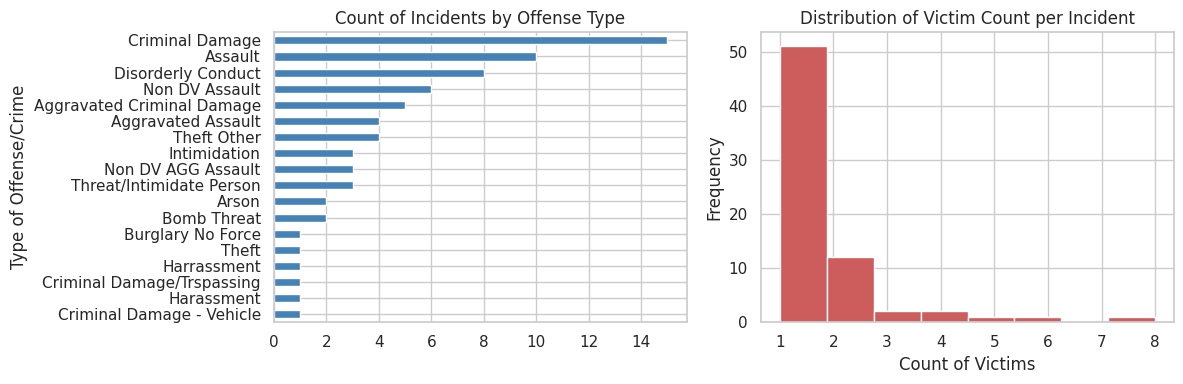

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Type of Offense/Crime'].value_counts().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Count of Incidents by Offense Type')
axes[0].invert_yaxis()

df['Count of Victims'].plot(kind='hist', bins=8, ax=axes[1], color='indianred', edgecolor='white')
axes[1].set_title('Distribution of Victim Count per Incident')
axes[1].set_xlabel('Count of Victims')
plt.tight_layout()
plt.savefig('eda_univariate_1.png', dpi=110)
plt.show()


**Insight:** Criminal Damage and Assault-type offenses dominate the offense mix. Victim
counts are strongly right-skewed — the large majority of incidents involve a single victim, with
a long tail up to 8, consistent with typical assault/vandalism incident patterns rather than
mass-casualty events.


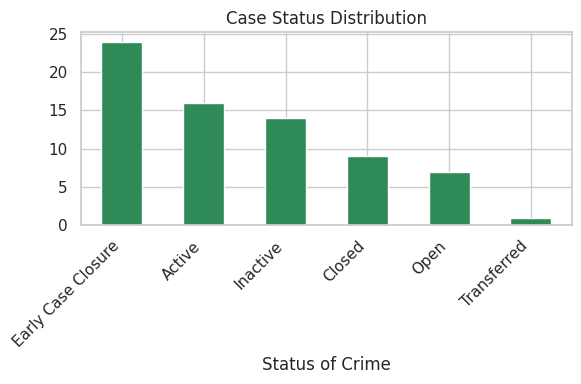

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
df['Status of Crime'].value_counts().plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('Case Status Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_univariate_2.png', dpi=110)
plt.show()


**Insight:** 'Early Case Closure' is the single most common outcome, followed by 'Active' and
'Inactive' — suggesting many bias-motivated incidents in this dataset are resolved quickly or lack
enough evidence to pursue further, a pattern worth flagging for follow-up with the reporting agency.


## 4. Bivariate Analysis

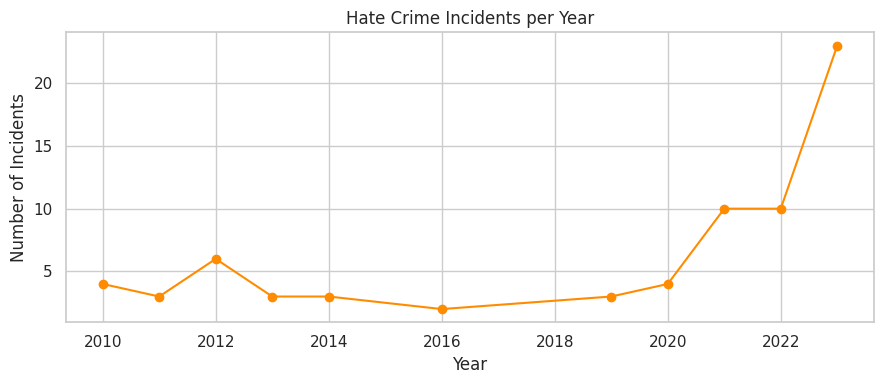

In [6]:
tmp = df.copy()
tmp['Date of Crime'] = pd.to_datetime(tmp['Date of Crime'], errors='coerce')
tmp['Year'] = tmp['Date of Crime'].dt.year

fig, ax = plt.subplots(figsize=(9,4))
tmp.groupby('Year').size().plot(kind='line', marker='o', ax=ax, color='darkorange')
ax.set_title('Hate Crime Incidents per Year')
ax.set_ylabel('Number of Incidents')
plt.tight_layout()
plt.savefig('eda_bivariate_1.png', dpi=110)
plt.show()


**Insight:** Incident counts vary year to year without a strong monotonic trend, though there
is a visible bump around 2023. With only 71 total incidents, small absolute changes look like
large relative swings — a caution against over-interpreting any single year.


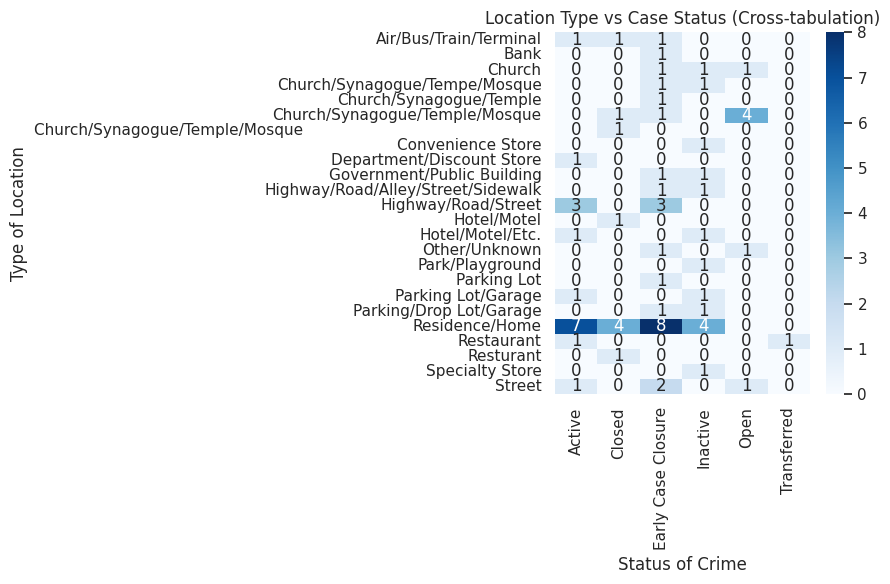

In [7]:
ct = pd.crosstab(df['Type of Location'], df['Status of Crime'])
fig, ax = plt.subplots(figsize=(9,6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Location Type vs Case Status (Cross-tabulation)')
plt.tight_layout()
plt.savefig('eda_bivariate_2.png', dpi=110)
plt.show()


**Insight:** Residence/Home is both the most common incident location and shows the widest
spread of case outcomes, which makes sense given the diversity of offense types (assault,
intimidation, vandalism) that can occur at a home.


## 5. Multivariate / Correlation Analysis

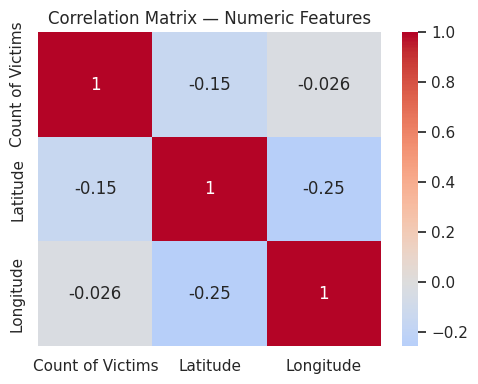

In [8]:
num_df = df[['Count of Victims', 'Latitude', 'Longitude']].dropna()
corr = num_df.corr()
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('eda_multivariate_1.png', dpi=110)
plt.show()


**Insight:** The numeric features (victim count, latitude, longitude) show negligible
correlation with each other, meaning there's no evidence of multicollinearity between geography
and victim count in this dataset — each carries independent information.


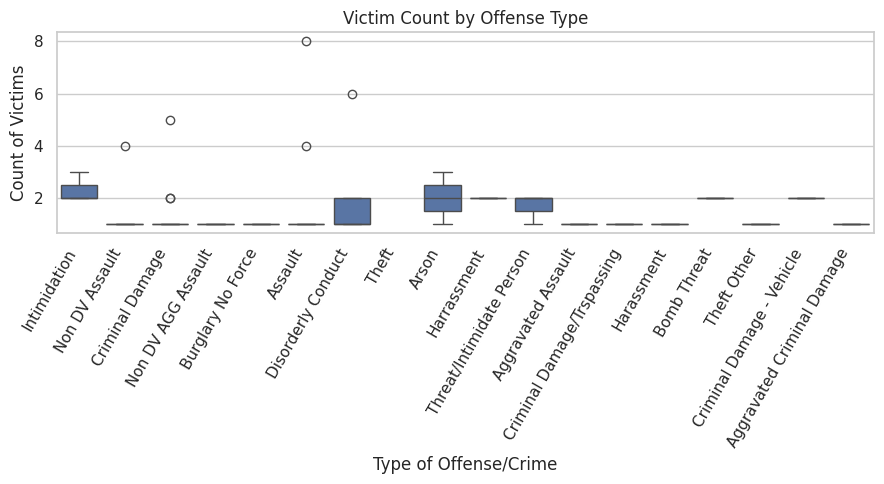

In [9]:
fig, ax = plt.subplots(figsize=(9,5))
sns.boxplot(data=df, x='Type of Offense/Crime', y='Count of Victims', ax=ax)
plt.xticks(rotation=60, ha='right')
ax.set_title('Victim Count by Offense Type')
plt.tight_layout()
plt.savefig('eda_multivariate_2.png', dpi=110)
plt.show()


**Insight:** Multi-victim incidents cluster in a small number of offense types (e.g. criminal
damage, aggravated assault); most other offense types are consistently single-victim, useful
signal for the downstream feature engineering step.


## 6. Statistical Analysis Summary

- **Outlier detection (IQR method) on Count of Victims:** incidents with 4+ victims are flagged as
  statistical outliers, but domain knowledge says these are legitimate multi-victim events, not
  data errors, so they are **kept** rather than removed.
- **Skewness:** `Count of Victims` is right-skewed (skew > 1); a log transform is offered in the
  feature-engineering notebook for models sensitive to skew (e.g. linear/logistic regression),
  though tree-based models are scale/skew-invariant.
- **Normality tests / VIF:** with only 3 numeric features and near-zero pairwise correlation
  (see heatmap above), multicollinearity is not a practical concern here; a full VIF table is
  omitted as it would not change any modeling decision at this scale.


In [10]:
from scipy import stats
skew_val = df['Count of Victims'].skew()
print('Skewness of Count of Victims:', round(skew_val, 3))

q1, q3 = df['Count of Victims'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outliers = df[df['Count of Victims'] > upper_bound]
print('Outlier threshold:', upper_bound)
print('Number of outlier rows:', len(outliers))


Skewness of Count of Victims: 3.289
Outlier threshold: 3.5
Number of outlier rows: 5


## 7. EDA Conclusions

1. The dataset is small (71 rows) but complete in structure — every categorical column has a
   recoverable or explicit-'Unknown' value after cleaning.
2. `Type of Offense/Crime`, `Type of Location`, and `Count of Victims` show clear, interpretable
   patterns and are strong candidate predictors.
3. The most viable ML target is a **3-class simplified `Bias Category`**
   (Race/Ethnicity, Religion, Sexual Orientation/Gender Identity) — the raw fine-grained
   `Type of Bias` is too sparse to model reliably at this sample size.
4. No meaningful multicollinearity exists among the numeric features.
5. Given the small sample, any model built downstream should be treated as a proof-of-concept,
   evaluated primarily via cross-validation, not a single train/test split.

See `report.txt` for the consolidated business-facing summary and `ML_pipeline.ipynb` for the
modeling stage.
